# Configuración básica (no tocar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [2]:
x = Variable()

# Implementación de métodos

In [3]:
# Implementar para hallar raíces de las derivadas, no de f

#Método de Bisección
def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000, return_path: bool = False):
    g = f.derivative()
    fa = g.eval(a)
    fb = g.eval(b)
    if fa == 0:
        return (a, 0, [a]) if return_path else (a, 0)
    if fb == 0:
        return (b, 0, [b]) if return_path else (b, 0)
    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en el intervalo dado.")
    path = []
    xn = a
    for step in range(1, max_iter + 1):
        xn = 0.5 * (a + b)
        path.append(xn)
        fxn = g.eval(xn)
        if abs(fxn) < tol or 0.5 * (b - a) < tol:
            return (xn, step, path) if return_path else (xn, step)
        if fa * fxn > 0:
            a = xn
            fa = fxn
        else:
            b = xn
            fb = fxn
    return (xn, max_iter, path) if return_path else (xn, max_iter)

#Método de Newton
def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000, return_path: bool = False):
    g = f.derivative()
    g2 = g.derivative()
    xn = x0
    path = [xn]
    for step in range(1, max_iter + 1):
        gx = g.eval(xn)
        if abs(gx) < tol:
            return (xn, step, path) if return_path else (xn, step)
        g2x = g2.eval(xn)
        if abs(g2x) < 1e-12:
            return (xn, step, path) if return_path else (xn, step)
        xn_next = xn - gx / g2x
        path.append(xn_next)
        if abs(xn_next - xn) < tol:
            return (xn_next, step, path) if return_path else (xn_next, step)
        xn = xn_next
    return (xn, max_iter, path) if return_path else (xn, max_iter)

#Método de Descenso por Gradiente
def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000, return_path: bool = False):
    grad = f.derivative()
    xn = x0
    path = [xn]
    for step in range(1, max_iter + 1):
        gx = grad.eval(xn)
        if abs(gx) < tol:
            return (xn, step, path) if return_path else (xn, step)
        xn_next = xn - lr * gx
        path.append(xn_next)
        if abs(xn_next - xn) < tol:
            return (xn_next, step, path) if return_path else (xn_next, step)
        xn = xn_next
    return (xn, max_iter, path) if return_path else (xn, max_iter)

### Prueba de métodos

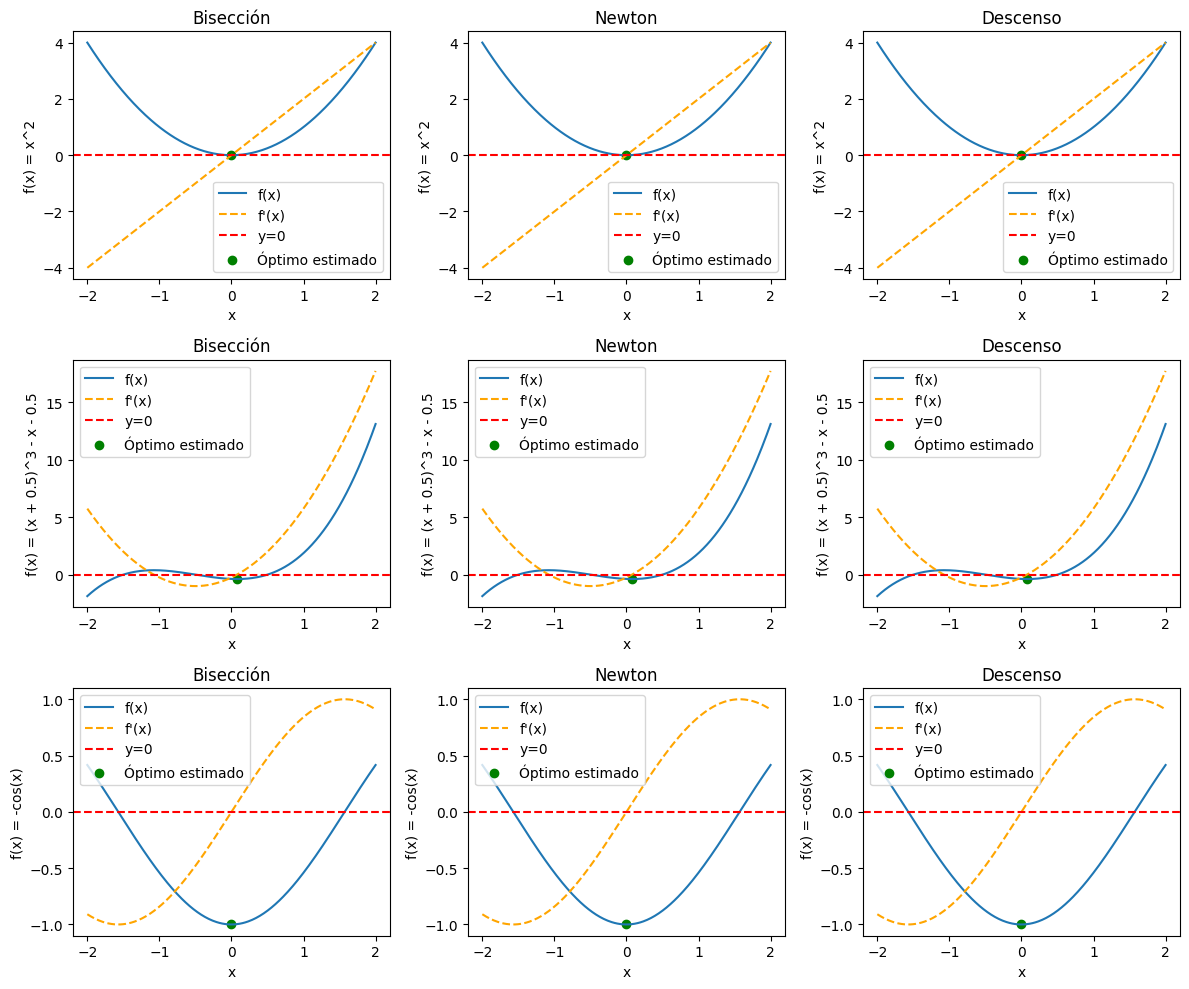

In [4]:
#Verificación de métodos con funciones simples
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        metodo = methods[j]
        params = parameters[j]
        res, step = metodo(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

In [5]:
# Verificación de funcionamiento
print("\nVerificación de los valores de extremo esperados:")
for i, f in enumerate(functions):
    name = y_labels[i]
    res_bis, _ = biseccion(f, -1, 1)
    res_new, _ = newton(f, 1)
    res_gd, _ = descenso_gradiente(f, 1, 1e-2)

    if i == 0:
        expected = [0.0]
        expected_desc = "x=0"
    elif i == 1:
        expected = [-0.5 - 1/np.sqrt(3), -0.5 + 1/np.sqrt(3)]
        expected_desc = "x ≈ -1.07735 o x ≈ 0.07735"
    else:
        expected = [0.0]
        expected_desc = "x=0 (raíz más cercana de -sin(x) en [-1,1])"

    def check(value):
        return any(np.isclose(value, e, atol=1e-4) for e in expected)

    print(f"\n{name}")
    print(f"  Bisección -> {res_bis}  {'OK' if check(res_bis) else 'ERROR'}")
    print(f"  Newton -> {res_new}  {'OK' if check(res_new) else 'ERROR'}")
    print(f"  Descenso -> {res_gd}  {'OK' if check(res_gd) else 'ERROR'}")
    print(f"  Esperado: {expected_desc}")


Verificación de los valores de extremo esperados:

f(x) = x^2
  Bisección -> 0.0  OK
  Newton -> 0.0  OK
  Descenso -> 4.8220225910828e-05  OK
  Esperado: x=0

f(x) = (x + 0.5)^3 - x - 0.5
  Bisección -> 0.07734966278076172  OK
  Newton -> 0.07735026919569789  OK
  Descenso -> 0.07737808501133076  OK
  Esperado: x ≈ -1.07735 o x ≈ 0.07735

f(x) = -cos(x)
  Bisección -> 0.0  OK
  Newton -> 2.923566201412306e-13  OK
  Descenso -> 9.836982761146878e-05  OK
  Esperado: x=0 (raíz más cercana de -sin(x) en [-1,1])


# Aplicación a función no trivial

In [6]:
f = x**2 + 2*sin(3*x)

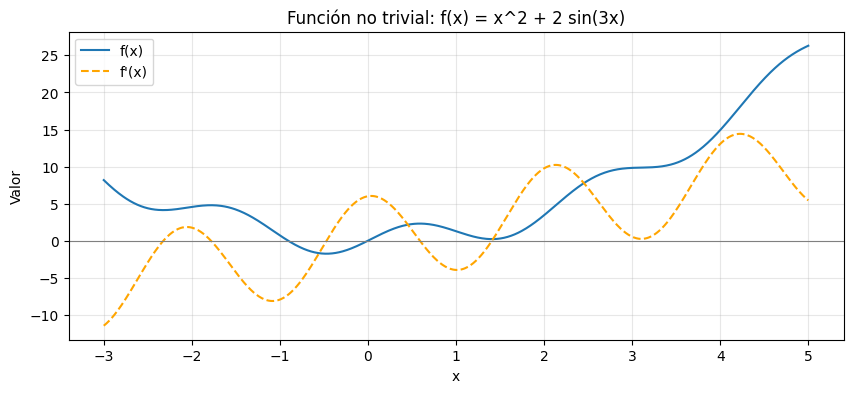

In [7]:
# Gráfica de la función para el intervalo [-3,5]
lp = np.linspace(-3, 5, 800)
plt.figure(figsize=(10, 4))
plt.plot(lp, [f.eval(v) for v in lp], label='f(x)')
plt.plot(lp, [f.derivative().eval(v) for v in lp], linestyle='--', color='orange', label="f'(x)")
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('x')
plt.ylabel('Valor')
plt.title('Función no trivial: f(x) = x^2 + 2 sin(3x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

             Método Condición inicial                                                 Predicción  Resultado  Iteraciones
          Bisección           [-2, 1]                                  raíz de f' cerca de -1.78  -1.782932           22
          Bisección           [-1, 0]                                  raíz de f' cerca de -0.47  -0.471044           20
          Bisección            [1, 2]                                   raíz de f' cerca de 1.41   1.407956           20
             Newton           x0 = -2             aproxima el mínimo local izquierdo (x ≈ -1.78)  -1.782932            5
             Newton           x0 = -1                 puede cambiar a la raíz central (x ≈ 0.59)   0.589531            5
             Newton            x0 = 4 puede desviarse hacia la región derecha (no converge bien)   7.820892         1000
  Descenso (lr=0.1)           x0 = -3      debería caer en el mínimo local izquierdo (x ≈ -2.32)  -2.322807           16
 Descenso (lr=0.01)           x0

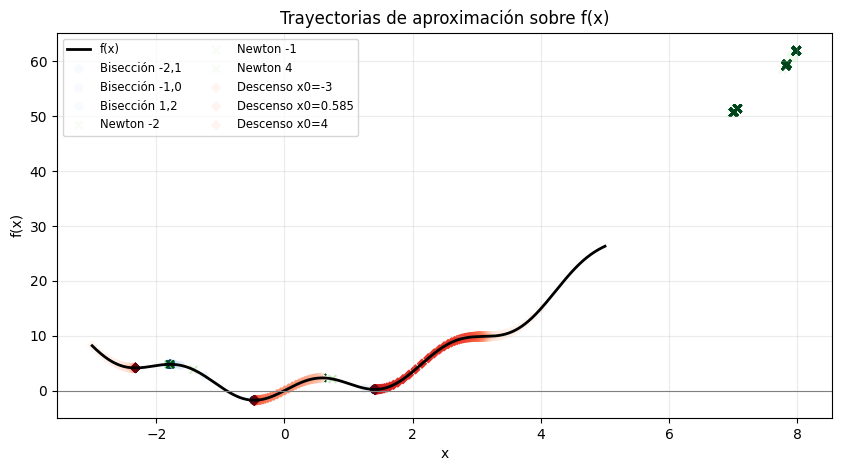

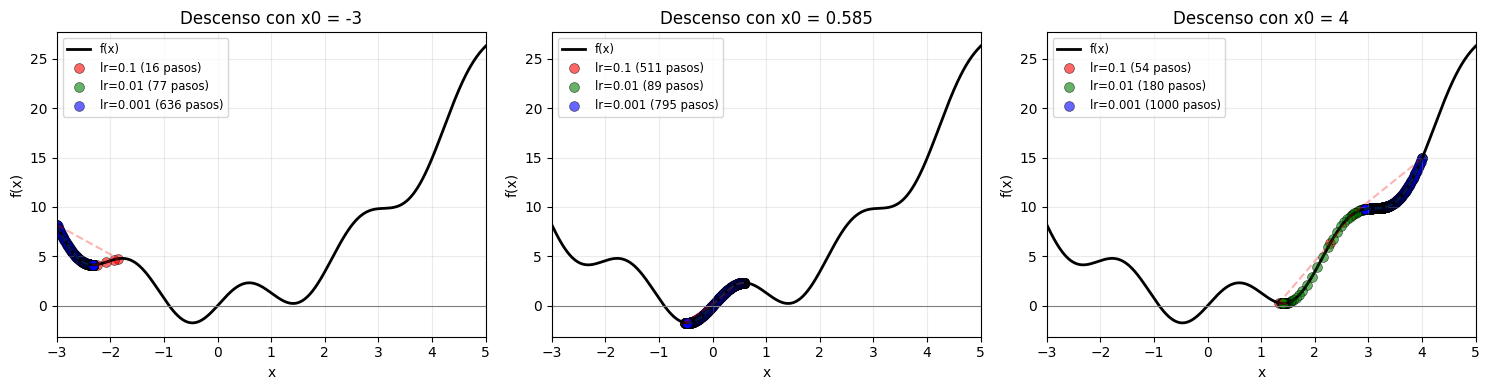

In [8]:
# Evaluación de métodos y generación de tablas
bisec_intervals = [(-2, 1), (-1, 0), (1, 2)]
newton_inits = [-2, -1, 4]
gd_inits = [-3, 0.585, 4]
learning_rates = [0.1, 0.01, 0.001]

rows = []
for a, b in bisec_intervals:
    prediction = {
        (-2, 1): 'raíz de f\' cerca de -1.78',
        (-1, 0): 'raíz de f\' cerca de -0.47',
        (1, 2): 'raíz de f\' cerca de 1.41'
    }[(a, b)]
    res, steps = biseccion(f, a, b)
    rows.append({'Método': 'Bisección', 'Condición inicial': f'[{a}, {b}]', 'Predicción': prediction, 'Resultado': res, 'Iteraciones': steps})

for x0 in newton_inits:
    prediction = {
        -2: 'aproxima el mínimo local izquierdo (x ≈ -1.78)',
        -1: 'puede cambiar a la raíz central (x ≈ 0.59)',
        4: 'puede desviarse hacia la región derecha (no converge bien)'
    }[x0]
    res, steps = newton(f, x0)
    rows.append({'Método': 'Newton', 'Condición inicial': f'x0 = {x0}', 'Predicción': prediction, 'Resultado': res, 'Iteraciones': steps})

for x0 in gd_inits:
    for lr in learning_rates:
        prediction = {
            -3: 'debería caer en el mínimo local izquierdo (x ≈ -2.32)',
            0.585: 'debería moverse al extremo central (x ≈ -0.47)',
            4: 'debería caer en el mínimo local derecho (x ≈ 1.41)'
        }[x0]
        res, steps = descenso_gradiente(f, x0, lr)
        rows.append({'Método': f'Descenso (lr={lr})', 'Condición inicial': f'x0 = {x0}', 'Predicción': prediction, 'Resultado': res, 'Iteraciones': steps})

summary_df = pd.DataFrame(rows)
print(summary_df.round(6).to_string(index=False))

import inspect

def _path_result(method, *args, **kwargs):
    try:
        return method(*args, return_path=True, **kwargs)
    except TypeError:
        res, steps = method(*args, **kwargs)
        return res, steps, [res]

# Comparación visual de trayectorias para cada método
plt.figure(figsize=(10, 5))
plt.plot(lp, [f.eval(v) for v in lp], label='f(x)', color='black', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.8)

palette = {'Bisección': 'tab:blue', 'Newton': 'tab:green', 'Descenso': 'tab:red'}

for a, b in bisec_intervals:
    _, _, path = _path_result(biseccion, f, a, b)
    path_y = [f.eval(v) for v in path]
    plt.scatter(path, path_y, c=np.arange(len(path)), cmap='Blues', s=30, label=f'Bisección {a},{b}')

for x0 in newton_inits:
    _, _, path = _path_result(newton, f, x0)
    path_y = [f.eval(v) for v in path]
    plt.scatter(path, path_y, c=np.arange(len(path)), cmap='Greens', s=30, marker='x', label=f'Newton {x0}')

for x0 in [ -3, 0.585, 4 ]:
    _, _, path = _path_result(descenso_gradiente, f, x0, 0.01)
    path_y = [f.eval(v) for v in path]
    plt.scatter(path, path_y, c=np.arange(len(path)), cmap='Reds', s=20, marker='D', label=f'Descenso x0={x0}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectorias de aproximación sobre f(x)')
plt.legend(fontsize='small', ncol=2)
plt.grid(alpha=0.25)
plt.show()

# Comparación de learning rates en descenso por gradiente
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_lr = {0.1: 'red', 0.01: 'green', 0.001: 'blue'}

for idx, x0 in enumerate(gd_inits):
    ax = axes[idx]
    ax.plot(lp, [f.eval(v) for v in lp], label='f(x)', color='black', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8)
    
    for lr in learning_rates:
        _, steps, path = _path_result(descenso_gradiente, f, x0, lr)
        path_y = [f.eval(v) for v in path]
        ax.scatter(path, path_y, c=colors_lr[lr], s=50, alpha=0.6, 
                  label=f'lr={lr} ({steps} pasos)', marker='o', edgecolors='black', linewidth=0.5)
        # Línea conectando puntos para ver la trayectoria
        ax.plot(path, path_y, color=colors_lr[lr], alpha=0.3, linestyle='--')
    
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Descenso con x0 = {x0}')
    ax.legend(fontsize='small')
    ax.grid(alpha=0.25)
    ax.set_xlim(-3, 5)

plt.tight_layout()
plt.show()


# Ajuste de datos

In [9]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

,Dataset,Modelo,Cantidad de datos,w teórico aprox.,Rango de x,Media de y
0,Lineal,ŷ(x; w) = w·x,100,2.0000,"[-9.94, 9.81]",-1.6192
1,Exponencial,ŷ(x; w) = e^(w·x),100,0.2222,"[-9.94, 9.81]",1.8099
2,Senoidal,ŷ(x; w) = sin(w·x),100,1.5000,"[-9.94, 9.81]",-0.1458


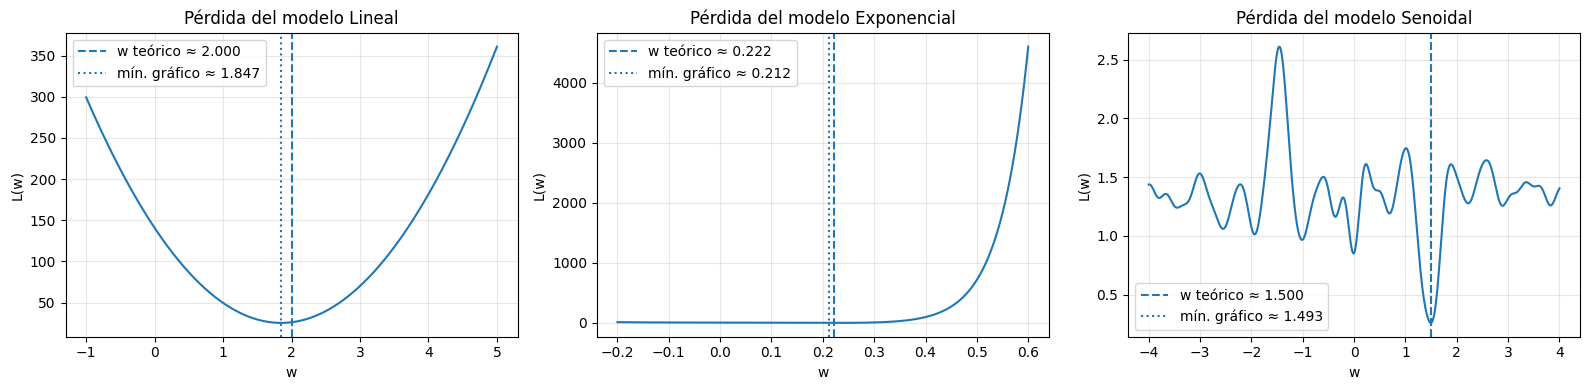

In [16]:
# Genere la función de pérdida

def obtener_xy(df):
    """Devuelve los arreglos x e y de un dataset."""
    return df["x"].to_numpy(dtype=float), df["y"].to_numpy(dtype=float)


def predecir(modelo, w_val, x_val):
    """
    Calcula la predicción del modelo y_hat(x; w).

    modelo puede ser:
    - 'Lineal'
    - 'Exponencial'
    - 'Senoidal'
    """
    if modelo == "Lineal":
        return w_val * x_val

    if modelo == "Exponencial":
        # Se usa clip para evitar overflow numérico en valores extremos.
        return np.exp(np.clip(w_val * x_val, -80, 80))

    if modelo == "Senoidal":
        return np.sin(w_val * x_val)

    raise ValueError("Modelo no reconocido.")


def perdida(modelo, w_val, x_data, y_data):
    """
    Función objetivo:

        L(w) = (1/N) * sum((y_hat(x_i; w) - y_i)^2)

    Un valor menor de L(w) indica un mejor ajuste del modelo a los datos.
    """
    y_hat = predecir(modelo, w_val, x_data)
    return np.mean((y_hat - y_data) ** 2)


def gradiente_perdida(modelo, w_val, x_data, y_data):
    """Derivada de L(w) respecto del parámetro w."""
    if modelo == "Lineal":
        y_hat = w_val * x_data
        return 2 * np.mean((y_hat - y_data) * x_data)

    if modelo == "Exponencial":
        z = np.clip(w_val * x_data, -80, 80)
        y_hat = np.exp(z)
        return 2 * np.mean((y_hat - y_data) * x_data * y_hat)

    if modelo == "Senoidal":
        y_hat = np.sin(w_val * x_data)
        return 2 * np.mean((y_hat - y_data) * x_data * np.cos(w_val * x_data))

    raise ValueError("Modelo no reconocido.")


def gradiente_individual(modelo, w_val, xi, yi):
    """
    Derivada del término individual:

        l_i(w) = (y_hat(x_i; w) - y_i)^2

    Se usa luego para implementar descenso por gradiente estocástico.
    """
    if modelo == "Lineal":
        y_hat = w_val * xi
        return 2 * (y_hat - yi) * xi

    if modelo == "Exponencial":
        z = np.clip(w_val * xi, -80, 80)
        y_hat = np.exp(z)
        return 2 * (y_hat - yi) * xi * y_hat

    if modelo == "Senoidal":
        y_hat = np.sin(w_val * xi)
        return 2 * (y_hat - yi) * xi * np.cos(w_val * xi)

    raise ValueError("Modelo no reconocido.")


datasets = {
    "Lineal": {
        "df": df_linear,
        "modelo_texto": "ŷ(x; w) = w·x",
        "w_esperado": 2.0,
        "w0": 0.0,
        "lr": 1e-2,
        "rango_w": (-1, 5)
    },
    "Exponencial": {
        "df": df_exp,
        "modelo_texto": "ŷ(x; w) = e^(w·x)",
        "w_esperado": 1 / 4.5,
        "w0": 0.0,
        "lr": 1e-3,
        "rango_w": (-0.2, 0.6)
    },
    "Senoidal": {
        "df": df_sin,
        "modelo_texto": "ŷ(x; w) = sin(w·x)",
        "w_esperado": 1.5,
        "w0": 1.4,
        "lr": 1e-3,
        "rango_w": (-4, 4)
    }
}


# Resumen de los datasets.
# Esta tabla es descriptiva: explica qué datos se van a ajustar antes de optimizar.
resumen_datasets = []

for nombre, info in datasets.items():
    x_data, y_data = obtener_xy(info["df"])

    resumen_datasets.append({
        "Dataset": nombre,
        "Modelo": info["modelo_texto"],
        "Cantidad de datos": len(x_data),
        "w teórico aprox.": f"{info['w_esperado']:.4f}",
        "Rango de x": f"[{x_data.min():.2f}, {x_data.max():.2f}]",
        "Media de y": f"{y_data.mean():.4f}"
    })

resumen_datasets_df = pd.DataFrame(resumen_datasets)
display(resumen_datasets_df)


# Gráfica de L(w) para cada dataset/modelo.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, info) in zip(axes, datasets.items()):
    x_data, y_data = obtener_xy(info["df"])

    w_min, w_max = info["rango_w"]
    w_grid = np.linspace(w_min, w_max, 1000)

    losses = np.array([
        perdida(nombre, w_val, x_data, y_data)
        for w_val in w_grid
    ])

    mejor_idx = int(np.argmin(losses))
    w_min_graf = w_grid[mejor_idx]

    ax.plot(w_grid, losses)
    ax.axvline(
        info["w_esperado"],
        linestyle="--",
        label=f"w teórico ≈ {info['w_esperado']:.3f}"
    )
    ax.axvline(
        w_min_graf,
        linestyle=":",
        label=f"mín. gráfico ≈ {w_min_graf:.3f}"
    )

    ax.set_title(f"Pérdida del modelo {nombre}")
    ax.set_xlabel("w")
    ax.set_ylabel("L(w)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

,Modelo,w inicial,learning rate,w teórico aprox.,w encontrado,L(w encontrado),Iteraciones
0,Lineal,0.0,0.010,2.000000,1.847994,25.242044,18
1,Exponencial,0.0,0.001,0.222222,0.212576,0.994378,16
2,Senoidal,1.4,0.001,1.500000,1.494980,0.259860,447


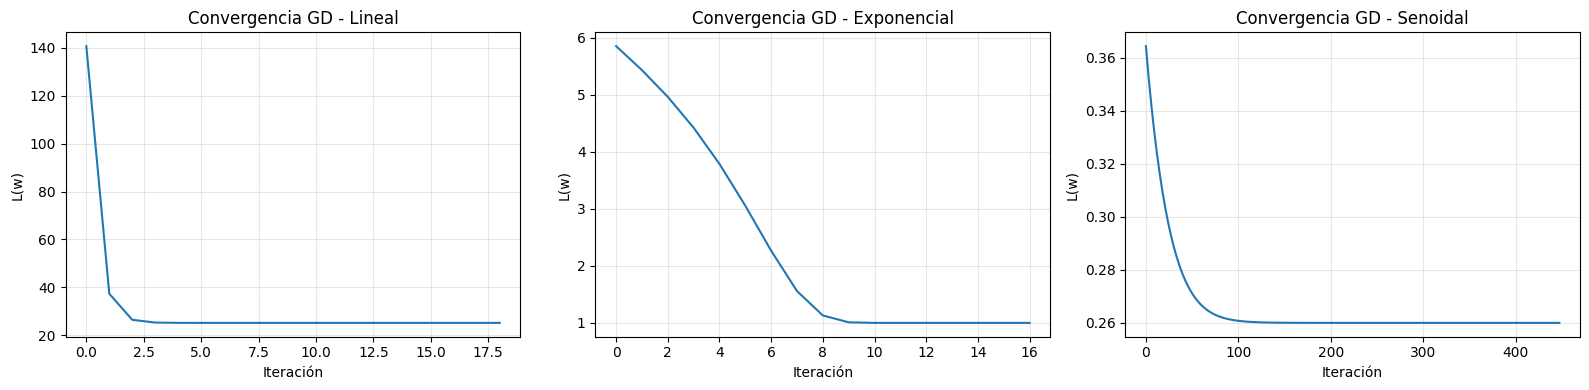

In [18]:
# Optimice la función de pérdida

def descenso_gradiente_parametro(modelo, x_data, y_data, w0, lr, tol=1e-8, max_iter=20000):
    """
    Descenso por gradiente clásico aplicado a la función de pérdida L(w).

    Parámetros:
    - modelo: nombre del modelo usado.
    - x_data, y_data: datos observados.
    - w0: valor inicial del parámetro w.
    - lr: learning rate.
    - tol: tolerancia para detener el algoritmo.
    - max_iter: cantidad máxima de iteraciones.

    Devuelve:
    - w encontrado.
    - cantidad de iteraciones.
    - historial de iteraciones.
    """
    w_actual = float(w0)
    historial = []

    for step in range(1, max_iter + 1):
        loss_actual = perdida(modelo, w_actual, x_data, y_data)
        grad_actual = gradiente_perdida(modelo, w_actual, x_data, y_data)

        historial.append({
            "iteracion": step - 1,
            "w": w_actual,
            "loss": loss_actual,
            "gradiente": grad_actual
        })

        # Si el gradiente es casi cero, estamos cerca de un mínimo local.
        if abs(grad_actual) < tol:
            return w_actual, step - 1, pd.DataFrame(historial)

        w_siguiente = w_actual - lr * grad_actual

        # Control de seguridad por si el método se vuelve numéricamente inestable.
        if not np.isfinite(w_siguiente):
            print(f"Advertencia: el método se volvió inestable para {modelo}.")
            return w_actual, step, pd.DataFrame(historial)

        # Si el cambio entre iteraciones es muy pequeño, detenemos el algoritmo.
        if abs(w_siguiente - w_actual) < tol:
            w_actual = w_siguiente

            historial.append({
                "iteracion": step,
                "w": w_actual,
                "loss": perdida(modelo, w_actual, x_data, y_data),
                "gradiente": gradiente_perdida(modelo, w_actual, x_data, y_data)
            })

            return w_actual, step, pd.DataFrame(historial)

        w_actual = w_siguiente

    return w_actual, max_iter, pd.DataFrame(historial)


# Aplicamos descenso por gradiente clásico a cada modelo.
resultados_ajuste = []
historiales_gd = {}

for nombre, info in datasets.items():
    x_data, y_data = obtener_xy(info["df"])

    w_opt, iteraciones, historial = descenso_gradiente_parametro(
        modelo=nombre,
        x_data=x_data,
        y_data=y_data,
        w0=info["w0"],
        lr=info["lr"],
        tol=1e-8,
        max_iter=20000
    )

    historiales_gd[nombre] = historial

    resultados_ajuste.append({
        "Modelo": nombre,
        "w inicial": info["w0"],
        "learning rate": info["lr"],
        "w teórico aprox.": info["w_esperado"],
        "w encontrado": w_opt,
        "L(w encontrado)": perdida(nombre, w_opt, x_data, y_data),
        "Iteraciones": iteraciones
    })


# Tabla resumen de la optimización.
# Esta tabla muestra el resultado final del descenso por gradiente para cada modelo.
resultados_ajuste_df = pd.DataFrame(resultados_ajuste)
display(resultados_ajuste_df)


# Gráfica de evolución de la pérdida durante el descenso por gradiente clásico.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, historial) in zip(axes, historiales_gd.items()):
    ax.plot(historial["iteracion"], historial["loss"])

    ax.set_title(f"Convergencia GD - {nombre}")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("L(w)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

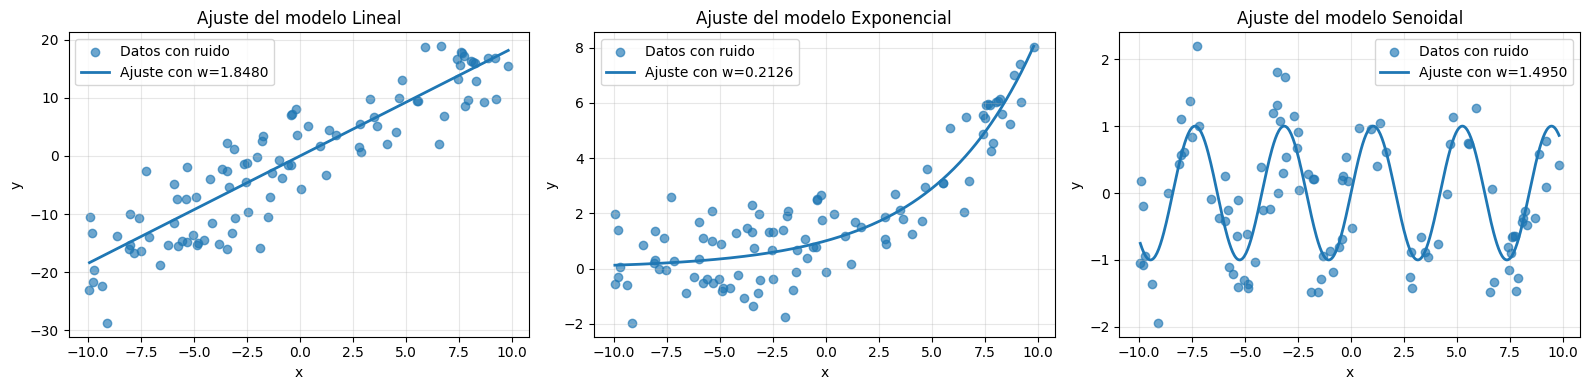

In [20]:
# Grafique datos y ajuste

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, info) in zip(axes, datasets.items()):
    x_data, y_data = obtener_xy(info["df"])

    w_opt = float(
        resultados_ajuste_df.loc[
            resultados_ajuste_df["Modelo"] == nombre,
            "w encontrado"
        ].iloc[0]
    )

    # Se genera una grilla ordenada para que la curva del modelo se vea continua.
    x_ordenado = np.linspace(x_data.min(), x_data.max(), 500)
    y_ajustado = predecir(nombre, w_opt, x_ordenado)

    ax.scatter(x_data, y_data, alpha=0.65, label="Datos con ruido")
    ax.plot(
        x_ordenado,
        y_ajustado,
        linewidth=2,
        label=f"Ajuste con w={w_opt:.4f}"
    )

    ax.set_title(f"Ajuste del modelo {nombre}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# BONUS:

,Modelo,Método,w inicial,learning rate,epochs,w encontrado,L(w encontrado),Actualizaciones
0,Lineal,SGD,0.0,0.0001,200,1.810494,25.289531,20000
1,Exponencial,SGD,0.0,0.0001,100,0.212501,0.994381,10000
2,Senoidal,SGD,1.4,0.0005,100,1.496538,0.259895,10000


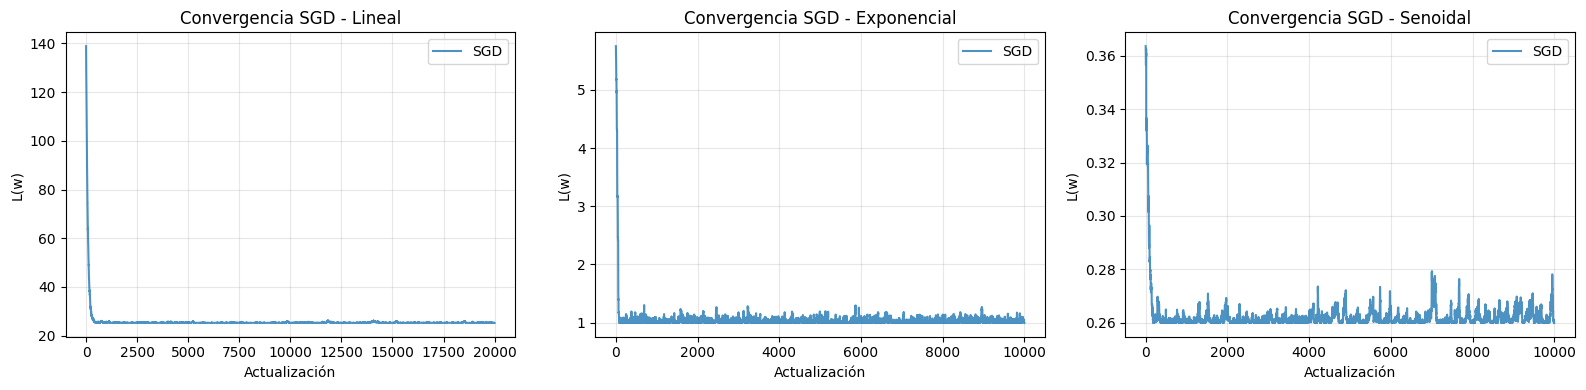

In [24]:
# ---------------------------------------------------------------------
# BONUS 1: Descenso por gradiente estocástico para ajuste de datos
# ---------------------------------------------------------------------

# Este bloque implementa SGD para los mismos tres modelos de la Parte 4:
# Lineal:       y_hat(x; w) = w*x
# Exponencial:  y_hat(x; w) = e^(w*x)
# Senoidal:     y_hat(x; w) = sin(w*x)

def predecir_bonus(modelo, w, x):
    """Predicción del modelo para un valor de w."""
    if modelo == "Lineal":
        return w * x
    elif modelo == "Exponencial":
        return np.exp(w * x)
    elif modelo == "Senoidal":
        return np.sin(w * x)
    else:
        raise ValueError(f"Modelo no reconocido: {modelo}")


def perdida_bonus(modelo, w, x_data, y_data):
    """Pérdida cuadrática media."""
    y_pred = predecir_bonus(modelo, w, x_data)
    return np.mean((y_pred - y_data) ** 2)


def gradiente_individual_bonus(modelo, w, xi, yi):
    """
    Gradiente de la pérdida individual:
        l_i(w) = (y_hat(x_i; w) - y_i)^2

    En SGD usamos un único dato por actualización.
    """
    if modelo == "Lineal":
        # y_hat = w*x
        # d/dw (w*x - y)^2 = 2(w*x - y)x
        y_pred = w * xi
        return 2 * (y_pred - yi) * xi

    elif modelo == "Exponencial":
        # y_hat = e^(w*x)
        # d/dw (e^(w*x) - y)^2 = 2(e^(w*x)-y) * x * e^(w*x)
        y_pred = np.exp(w * xi)
        return 2 * (y_pred - yi) * xi * y_pred

    elif modelo == "Senoidal":
        # y_hat = sin(w*x)
        # d/dw (sin(w*x) - y)^2 = 2(sin(w*x)-y) * x*cos(w*x)
        y_pred = np.sin(w * xi)
        return 2 * (y_pred - yi) * xi * np.cos(w * xi)

    else:
        raise ValueError(f"Modelo no reconocido: {modelo}")


def descenso_gradiente_estocastico(modelo, x_data, y_data, w0, lr, epochs=100, seed=42):
    """
    Descenso por Gradiente Estocástico (SGD).

    En cada actualización se elige aleatoriamente un dato (x_i, y_i)
    y se actualiza w usando únicamente el gradiente de ese dato.
    """
    rng = np.random.default_rng(seed)
    w_actual = float(w0)
    n = len(x_data)
    historial = []

    for step in range(epochs * n):
        i = rng.integers(n)

        grad_i = gradiente_individual_bonus(
            modelo=modelo,
            w=w_actual,
            xi=x_data[i],
            yi=y_data[i]
        )

        w_actual = w_actual - lr * grad_i
        loss_actual = perdida_bonus(modelo, w_actual, x_data, y_data)

        historial.append({
            "iteracion": step,
            "w": w_actual,
            "loss": loss_actual,
            "gradiente_individual": grad_i
        })

        if not np.isfinite(w_actual) or not np.isfinite(loss_actual):
            print(f"Advertencia: SGD se volvió inestable para el modelo {modelo}.")
            break

    return w_actual, len(historial), pd.DataFrame(historial)


# ---------------------------------------------------------------------
# Ejecutar SGD para los tres modelos
# ---------------------------------------------------------------------

config_sgd = {
    "Lineal": {
        "w0": 0.0,
        "lr": 1e-4,
        "epochs": 200
    },
    "Exponencial": {
        "w0": 0.0,
        "lr": 1e-4,
        "epochs": 100
    },
    "Senoidal": {
        "w0": 1.4,
        "lr": 5e-4,
        "epochs": 100
    }
}

resultados_sgd = []
historiales_sgd = {}

for nombre, info in datasets.items():
    x_data, y_data = obtener_xy(info["df"])
    cfg = config_sgd[nombre]

    w_sgd, actualizaciones, historial_sgd = descenso_gradiente_estocastico(
        modelo=nombre,
        x_data=x_data,
        y_data=y_data,
        w0=cfg["w0"],
        lr=cfg["lr"],
        epochs=cfg["epochs"],
        seed=42
    )

    historiales_sgd[nombre] = historial_sgd

    resultados_sgd.append({
        "Modelo": nombre,
        "Método": "SGD",
        "w inicial": cfg["w0"],
        "learning rate": cfg["lr"],
        "epochs": cfg["epochs"],
        "w encontrado": w_sgd,
        "L(w encontrado)": perdida_bonus(nombre, w_sgd, x_data, y_data),
        "Actualizaciones": actualizaciones
    })

resultados_sgd_df = pd.DataFrame(resultados_sgd)

display(resultados_sgd_df)


# ---------------------------------------------------------------------
# Gráfica: evolución de la pérdida con SGD
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, nombre in zip(axes, datasets.keys()):
    hist_sgd = historiales_sgd[nombre]

    ax.plot(
        hist_sgd["iteracion"],
        hist_sgd["loss"],
        label="SGD",
        alpha=0.8
    )

    ax.set_title(f"Convergencia SGD - {nombre}")
    ax.set_xlabel("Actualización")
    ax.set_ylabel("L(w)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("convergencia_sgd.png", dpi=300, bbox_inches="tight")
plt.show()


,x0,Método,lr inicial,beta,x encontrado,f(x encontrado),Iteraciones
0,-3.000,GD clásico lr fijo,0.1,-,-2.322807,4.129721,16
1,-3.000,GD lr variable,0.1,0.01,-2.322807,4.129721,13
2,0.585,GD clásico lr fijo,0.1,-,-0.471043,-1.753311,511
3,0.585,GD lr variable,0.1,0.01,-0.471043,-1.753311,33
4,4.000,GD clásico lr fijo,0.1,-,1.407957,0.216284,54
5,4.000,GD lr variable,0.1,0.01,1.407956,0.216284,25


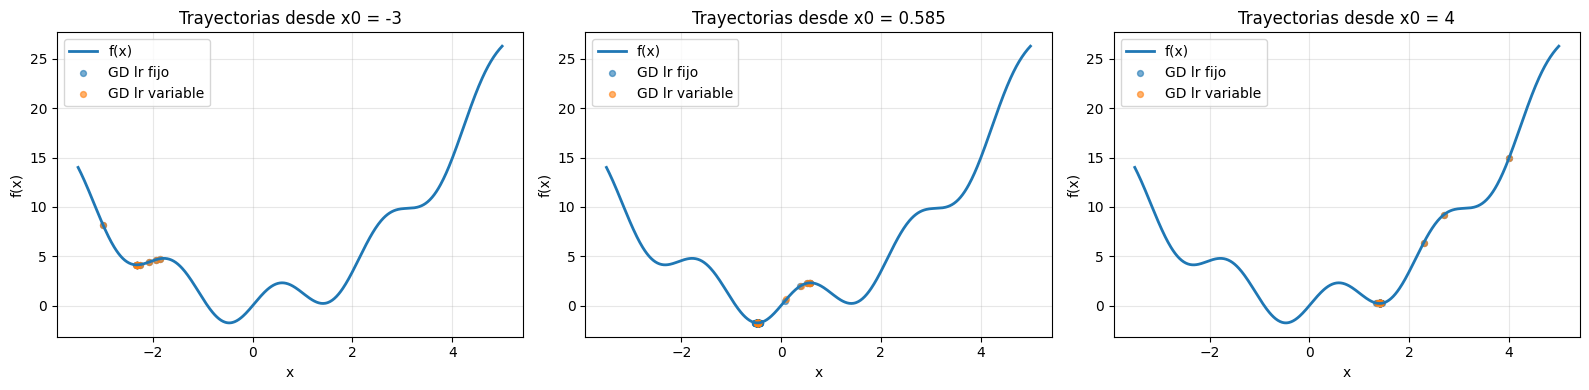

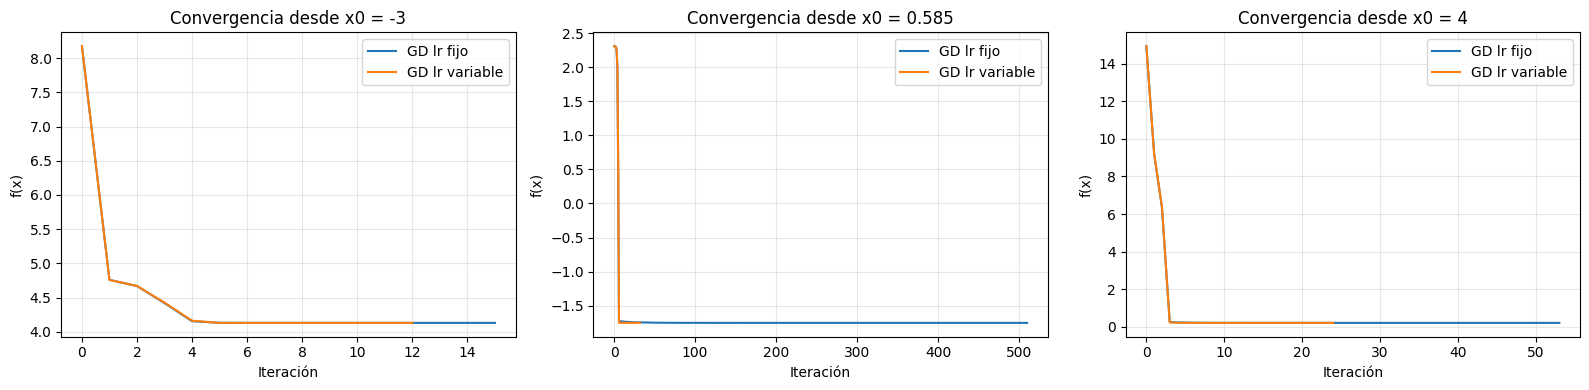

In [25]:
# ---------------------------------------------------------------------
# BONUS 2: Descenso por gradiente con learning rate variable
# ---------------------------------------------------------------------



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def f_no_trivial(x):
    """Función no trivial utilizada en la Parte 2."""
    return x**2 + 2 * np.sin(3 * x)


def df_no_trivial(x):
    """Derivada de f(x) = x^2 + 2 sin(3x)."""
    return 2 * x + 6 * np.cos(3 * x)


def descenso_gradiente_fijo(f, df, x0, lr=0.1, tol=1e-6, max_iter=1000):
    """
    Descenso por gradiente clásico con learning rate fijo.
    """
    x_actual = float(x0)
    historial = []

    for k in range(max_iter):
        grad = df(x_actual)
        x_nuevo = x_actual - lr * grad

        historial.append({
            "iteracion": k,
            "x": x_actual,
            "f(x)": f(x_actual),
            "gradiente": grad,
            "learning_rate": lr
        })

        if abs(x_nuevo - x_actual) < tol:
            x_actual = x_nuevo
            break

        if not np.isfinite(x_nuevo):
            print(f"Advertencia: divergencia con lr fijo para x0={x0}")
            break

        x_actual = x_nuevo

    return x_actual, f(x_actual), k + 1, pd.DataFrame(historial)


def descenso_gradiente_lr_variable(f, df, x0, alpha0=0.1, beta=0.01, tol=1e-6, max_iter=1000):
    """
    Descenso por gradiente con learning rate variable.

    Se utiliza una estrategia de decaimiento:
        alpha_n = alpha0 / (1 + beta*n)

    De esta forma, el método comienza con pasos más grandes y luego
    reduce progresivamente el tamaño del paso.
    """
    x_actual = float(x0)
    historial = []

    for k in range(max_iter):
        alpha_n = alpha0 / (1 + beta * k)
        grad = df(x_actual)
        x_nuevo = x_actual - alpha_n * grad

        historial.append({
            "iteracion": k,
            "x": x_actual,
            "f(x)": f(x_actual),
            "gradiente": grad,
            "learning_rate": alpha_n
        })

        if abs(x_nuevo - x_actual) < tol:
            x_actual = x_nuevo
            break

        if not np.isfinite(x_nuevo):
            print(f"Advertencia: divergencia con lr variable para x0={x0}")
            break

        x_actual = x_nuevo

    return x_actual, f(x_actual), k + 1, pd.DataFrame(historial)


# ---------------------------------------------------------------------
# Ejecutar comparación para distintas condiciones iniciales
# ---------------------------------------------------------------------

condiciones_iniciales = [-3, 0.585, 4]

resultados_lr_variable = []
historiales_lr = {}

for x0 in condiciones_iniciales:

    # Descenso clásico con learning rate fijo
    x_fijo, f_fijo, iter_fijo, hist_fijo = descenso_gradiente_fijo(
        f=f_no_trivial,
        df=df_no_trivial,
        x0=x0,
        lr=0.1,
        tol=1e-6,
        max_iter=1000
    )

    # Descenso con learning rate variable
    x_var, f_var, iter_var, hist_var = descenso_gradiente_lr_variable(
        f=f_no_trivial,
        df=df_no_trivial,
        x0=x0,
        alpha0=0.1,
        beta=0.01,
        tol=1e-6,
        max_iter=1000
    )

    historiales_lr[x0] = {
        "fijo": hist_fijo,
        "variable": hist_var
    }

    resultados_lr_variable.append({
        "x0": x0,
        "Método": "GD clásico lr fijo",
        "lr inicial": 0.1,
        "beta": "-",
        "x encontrado": x_fijo,
        "f(x encontrado)": f_fijo,
        "Iteraciones": iter_fijo
    })

    resultados_lr_variable.append({
        "x0": x0,
        "Método": "GD lr variable",
        "lr inicial": 0.1,
        "beta": 0.01,
        "x encontrado": x_var,
        "f(x encontrado)": f_var,
        "Iteraciones": iter_var
    })


resultados_lr_variable_df = pd.DataFrame(resultados_lr_variable)

display(resultados_lr_variable_df)


# ---------------------------------------------------------------------
# Gráfica comparativa: trayectoria sobre la función
# ---------------------------------------------------------------------

x_plot = np.linspace(-3.5, 5, 600)
y_plot = f_no_trivial(x_plot)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, x0 in zip(axes, condiciones_iniciales):
    hist_fijo = historiales_lr[x0]["fijo"]
    hist_var = historiales_lr[x0]["variable"]

    ax.plot(x_plot, y_plot, label="f(x)", linewidth=2)

    ax.scatter(
        hist_fijo["x"],
        hist_fijo["f(x)"],
        s=18,
        alpha=0.6,
        label="GD lr fijo"
    )

    ax.scatter(
        hist_var["x"],
        hist_var["f(x)"],
        s=18,
        alpha=0.6,
        label="GD lr variable"
    )

    ax.set_title(f"Trayectorias desde x0 = {x0}")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("lr_variable_trayectorias.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------
# Gráfica comparativa: evolución del valor de f(x)
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, x0 in zip(axes, condiciones_iniciales):
    hist_fijo = historiales_lr[x0]["fijo"]
    hist_var = historiales_lr[x0]["variable"]

    ax.plot(
        hist_fijo["iteracion"],
        hist_fijo["f(x)"],
        label="GD lr fijo"
    )

    ax.plot(
        hist_var["iteracion"],
        hist_var["f(x)"],
        label="GD lr variable"
    )

    ax.set_title(f"Convergencia desde x0 = {x0}")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("f(x)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("lr_variable_convergencia.png", dpi=300, bbox_inches="tight")
plt.show()

,Método,Objetivo,w encontrado,MSE,Suma errores cuadrados,log(P(w)),P(w) directo,Iteraciones
0,Mínimos cuadrados analítico,Minimizar suma de errores cuadrados,1.847994,25.242044,2524.204378,-2524.204378,0.0,-
1,GD sobre MSE,Minimizar MSE,1.847994,25.242044,2524.204378,-2524.204378,0.0,18
2,GD sobre -log(P),Maximizar producto de exponenciales,1.847994,25.242044,2524.204378,-2524.204378,0.0,18


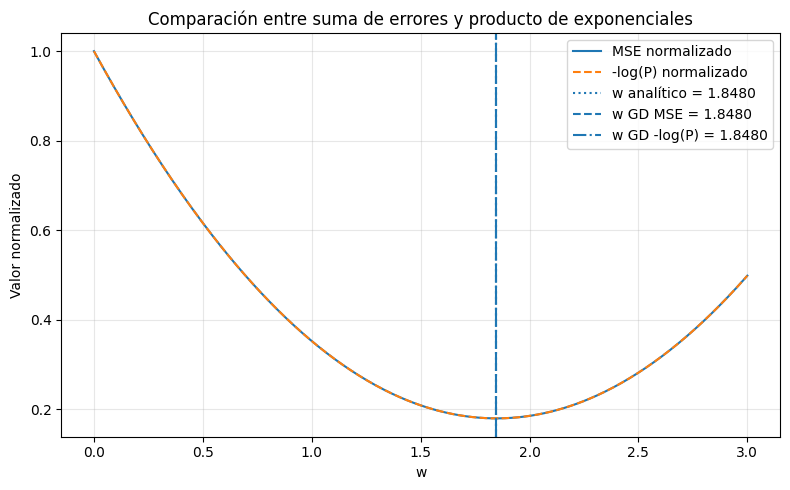

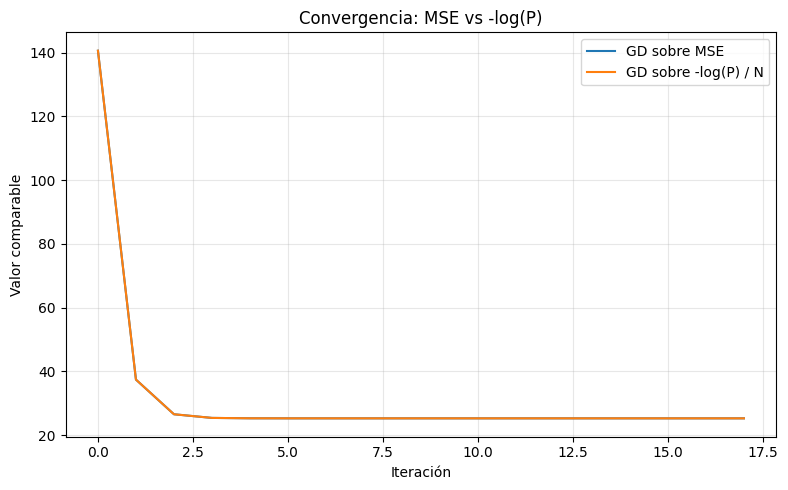

In [27]:
# ---------------------------------------------------------------------
# BONUS 3: Producto de exponenciales contra suma de errores cuadrados
# ---------------------------------------------------------------------



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Datos del modelo lineal
# ---------------------------------------------------------------------

x_lineal, y_lineal = obtener_xy(datasets["Lineal"]["df"])


# ---------------------------------------------------------------------
# Funciones objetivo
# ---------------------------------------------------------------------

def suma_errores_cuadrados_lineal(w, x_data, y_data):
    """
    S(w) = sum((w*x_i - y_i)^2)
    """
    errores = w * x_data - y_data
    return np.sum(errores ** 2)


def mse_lineal(w, x_data, y_data):
    """
    L(w) = mean((w*x_i - y_i)^2)
    """
    errores = w * x_data - y_data
    return np.mean(errores ** 2)


def producto_exponenciales_lineal(w, x_data, y_data):
    """
    P(w) = product(exp(-(w*x_i - y_i)^2))

    Esta forma puede tener problemas numéricos porque el producto
    de muchos valores muy pequeños puede redondearse a cero.
    """
    errores = w * x_data - y_data
    return np.prod(np.exp(-(errores ** 2)))


def log_producto_lineal(w, x_data, y_data):
    """
    log(P(w)) = -sum((w*x_i - y_i)^2)

    Se usa para evitar underflow numérico.
    """
    errores = w * x_data - y_data
    return -np.sum(errores ** 2)


def perdida_log_producto_lineal(w, x_data, y_data):
    """
    -log(P(w)) = sum((w*x_i - y_i)^2)

    Minimizar esta función equivale a maximizar el producto.
    """
    return -log_producto_lineal(w, x_data, y_data)


# ---------------------------------------------------------------------
# Gradientes
# ---------------------------------------------------------------------

def gradiente_mse_lineal(w, x_data, y_data):
    """
    Gradiente de la pérdida media:
        L(w) = mean((w*x_i - y_i)^2)
    """
    errores = w * x_data - y_data
    return 2 * np.mean(errores * x_data)


def gradiente_suma_lineal(w, x_data, y_data):
    """
    Gradiente de:
        S(w) = sum((w*x_i - y_i)^2)
    """
    errores = w * x_data - y_data
    return 2 * np.sum(errores * x_data)


# ---------------------------------------------------------------------
# Descenso por gradiente genérico en una dimensión
# ---------------------------------------------------------------------

def descenso_generico_lineal(funcion, gradiente, x_data, y_data, w0, lr, tol=1e-8, max_iter=1000):
    """
    Descenso por gradiente para una función objetivo dependiente de w.
    """
    w_actual = float(w0)
    historial = []

    for k in range(max_iter):
        valor_actual = funcion(w_actual, x_data, y_data)
        grad = gradiente(w_actual, x_data, y_data)

        historial.append({
            "iteracion": k,
            "w": w_actual,
            "valor_objetivo": valor_actual,
            "gradiente": grad
        })

        w_nuevo = w_actual - lr * grad

        if abs(w_nuevo - w_actual) < tol:
            w_actual = w_nuevo
            break

        if not np.isfinite(w_nuevo):
            print("Advertencia: el método se volvió inestable.")
            break

        w_actual = w_nuevo

    return w_actual, funcion(w_actual, x_data, y_data), k + 1, pd.DataFrame(historial)


# ---------------------------------------------------------------------
# Optimización
# ---------------------------------------------------------------------

# Solución analítica por mínimos cuadrados para comparar
w_analitico = np.sum(x_lineal * y_lineal) / np.sum(x_lineal ** 2)

# Optimización de MSE
w_mse, valor_mse, iter_mse, hist_mse = descenso_generico_lineal(
    funcion=mse_lineal,
    gradiente=gradiente_mse_lineal,
    x_data=x_lineal,
    y_data=y_lineal,
    w0=0.0,
    lr=0.01,
    tol=1e-8,
    max_iter=1000
)

# Optimización de -log(P), que equivale a suma de errores cuadrados
# Usamos lr más chico porque la suma tiene escala mayor que la media.
w_logprod, valor_logprod, iter_logprod, hist_logprod = descenso_generico_lineal(
    funcion=perdida_log_producto_lineal,
    gradiente=gradiente_suma_lineal,
    x_data=x_lineal,
    y_data=y_lineal,
    w0=0.0,
    lr=0.0001,
    tol=1e-8,
    max_iter=1000
)


# ---------------------------------------------------------------------
# Tabla comparativa
# ---------------------------------------------------------------------

resultados_producto_vs_suma = pd.DataFrame([
    {
        "Método": "Mínimos cuadrados analítico",
        "Objetivo": "Minimizar suma de errores cuadrados",
        "w encontrado": w_analitico,
        "MSE": mse_lineal(w_analitico, x_lineal, y_lineal),
        "Suma errores cuadrados": suma_errores_cuadrados_lineal(w_analitico, x_lineal, y_lineal),
        "log(P(w))": log_producto_lineal(w_analitico, x_lineal, y_lineal),
        "P(w) directo": producto_exponenciales_lineal(w_analitico, x_lineal, y_lineal),
        "Iteraciones": "-"
    },
    {
        "Método": "GD sobre MSE",
        "Objetivo": "Minimizar MSE",
        "w encontrado": w_mse,
        "MSE": mse_lineal(w_mse, x_lineal, y_lineal),
        "Suma errores cuadrados": suma_errores_cuadrados_lineal(w_mse, x_lineal, y_lineal),
        "log(P(w))": log_producto_lineal(w_mse, x_lineal, y_lineal),
        "P(w) directo": producto_exponenciales_lineal(w_mse, x_lineal, y_lineal),
        "Iteraciones": iter_mse
    },
    {
        "Método": "GD sobre -log(P)",
        "Objetivo": "Maximizar producto de exponenciales",
        "w encontrado": w_logprod,
        "MSE": mse_lineal(w_logprod, x_lineal, y_lineal),
        "Suma errores cuadrados": suma_errores_cuadrados_lineal(w_logprod, x_lineal, y_lineal),
        "log(P(w))": log_producto_lineal(w_logprod, x_lineal, y_lineal),
        "P(w) directo": producto_exponenciales_lineal(w_logprod, x_lineal, y_lineal),
        "Iteraciones": iter_logprod
    }
])

display(resultados_producto_vs_suma)


# ---------------------------------------------------------------------
# Gráfica 1: comparación de funciones objetivo
# ---------------------------------------------------------------------

w_vals = np.linspace(0, 3, 400)

mse_vals = np.array([mse_lineal(w, x_lineal, y_lineal) for w in w_vals])
neg_logprod_vals = np.array([perdida_log_producto_lineal(w, x_lineal, y_lineal) for w in w_vals])

# Normalizamos para comparar la forma en la misma escala visual
mse_norm = mse_vals / np.max(mse_vals)
neg_logprod_norm = neg_logprod_vals / np.max(neg_logprod_vals)

plt.figure(figsize=(8, 5))

plt.plot(w_vals, mse_norm, label="MSE normalizado")
plt.plot(w_vals, neg_logprod_norm, "--", label="-log(P) normalizado")

plt.axvline(w_analitico, linestyle=":", label=f"w analítico = {w_analitico:.4f}")
plt.axvline(w_mse, linestyle="--", label=f"w GD MSE = {w_mse:.4f}")
plt.axvline(w_logprod, linestyle="-.", label=f"w GD -log(P) = {w_logprod:.4f}")

plt.title("Comparación entre suma de errores y producto de exponenciales")
plt.xlabel("w")
plt.ylabel("Valor normalizado")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("producto_vs_suma_funciones.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------
# Gráfica 2: convergencia de ambos métodos
# ---------------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    hist_mse["iteracion"],
    hist_mse["valor_objetivo"],
    label="GD sobre MSE"
)

# Para comparar visualmente, dividimos la suma entre N y queda en escala de MSE.
plt.plot(
    hist_logprod["iteracion"],
    hist_logprod["valor_objetivo"] / len(x_lineal),
    label="GD sobre -log(P) / N"
)

plt.title("Convergencia: MSE vs -log(P)")
plt.xlabel("Iteración")
plt.ylabel("Valor comparable")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("producto_vs_suma_convergencia.png", dpi=300, bbox_inches="tight")
plt.show()


